# 图记忆

## 长期记忆
### 长期记忆存储
- store.put(namespace, key, value)
    - namespace必须是元组，天然分层
- 可内存存储，也可存数据库，表名为`store`

In [2]:
from typing import Final, Tuple
from langgraph.store.postgres import PostgresStore

from common import load_postgresql_url

with PostgresStore.from_conn_string(load_postgresql_url()) as store:
    # setup() 创建长期记忆所需的表结构，幂等操作
    store.setup()

    # 命名空间 - 层级结构：("users", "用户名")
    # Final 的作用是告诉静态类型检查器，该变量不应该被重新赋值，但 python 运行时不会阻止重新赋值
    USERS_NS: Final[Tuple[str]] = ("users", )
    PREFERENCES_KEY: Final[str] = "preferences"

    # 三层: (领域, 用户实体)
    # 每个 key 存储该用户的不同类型数据
    namespace1 = (*USERS_NS, "Alice")
    value1 = {
        "course": "计算机组成原理",
        "sports": "跑步",
        "food": "紫光园奶皮子酸奶"
    }

    namespace2 = (*USERS_NS, "Bob")
    value2 = {
        "course": "数字电路与模拟电路",
        "sports": "跑步",
        "food": "奶皮子糖葫芦"
    }

    namespace3 = (*USERS_NS, "Black")
    value3 = {
        "course": "数字电路与模拟电路",
        "sports": "羽毛球",
        "food": "紫光园奶皮子酸奶"
    }

    store.put(namespace1, PREFERENCES_KEY, value1)
    store.put(namespace2, PREFERENCES_KEY, value2)
    store.put(namespace3, PREFERENCES_KEY, value3)

    for item in store.search(USERS_NS):
        print(item)

Item(namespace=['users', 'Black'], key='preferences', value={'food': '紫光园奶皮子酸奶', 'course': '数字电路与模拟电路', 'sports': '羽毛球'}, created_at='2026-08-13T04:56:06.532607+00:00', updated_at='2026-08-13T04:56:06.532607+00:00', score=None)
Item(namespace=['users', 'Bob'], key='preferences', value={'food': '奶皮子糖葫芦', 'course': '数字电路与模拟电路', 'sports': '跑步'}, created_at='2026-08-13T04:56:06.482609+00:00', updated_at='2026-08-13T04:56:06.482609+00:00', score=None)
Item(namespace=['users', 'Alice'], key='preferences', value={'food': '紫光园奶皮子酸奶', 'course': '计算机组成原理', 'sports': '跑步'}, created_at='2026-08-13T04:56:06.422307+00:00', updated_at='2026-08-13T04:56:06.422307+00:00', score=None)


### 长期记忆检索

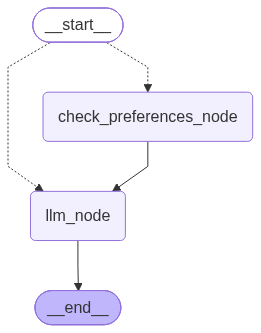

2026-08-13 13:40:10.295 | INFO     | __main__:router:47 - 用户偏好已存在，不必查询


============================== ->  <- ==============================


{
    'messages': [
        SystemMessage(
            content='请根据用户偏好解决用户需求',
            additional_kwargs={},
            response_metadata={},
            id='58b894b2-c53e-4ac3-a07d-14091f5b5c0b'
        ),
        HumanMessage(
            content="这是用户的偏好: \n{'food': '紫光园奶皮子酸奶', 'course': '计算机组成原理', 'sports': 
'跑步'}\n这是用户的需求: \n我有点无聊，和我聊聊天吧\n",
            additional_kwargs={},
            response_metadata={},
            id='668c4212-219a-4a7b-982b-a7a6c71e0454'
        ),
        AIMessage(
            content='哈喽！无聊的话我来陪你聊聊天呀~ 
\n\n今天是怎么啦？是刚学完“计算机组成原理”，觉得脑子被CPU、总线和指令周期绕晕了想放松一下，还是今天没去跑步，觉得浑
身不得劲？\n\n要是学计组学累了，不如转移一下注意力，想想好吃的犒劳一下自己？你最爱的那口“紫光园奶皮子酸奶”，浓郁香
甜的奶皮子配上醇厚顺滑的酸奶，想想是不是瞬间就馋了，心情也跟着好起来了？\n\n你想聊点啥呢？是想吐槽一下计组里那些让
人头秃的硬件知识，还是分享一下最近跑步的路线和配速，或者咱们就单纯聊聊紫光园还有啥其他好吃的？我都听你的！',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 688,
                    'prompt_tokens': 64,
                    'total_tokens': 752,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': None,
                        'audio_tokens': None,
                        'reasoning_tokens': 527,
                        'rejected_prediction_tokens': None,
                        'text_tokens': 688
                    },
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0, 'text_tokens': 64}
                },
                'model_provider': 'openai',
                'model_name': 'qwen3.7-plus',
                'system_fingerprint': None,
                'id': 'chatcmpl-8eb5a4af-38f1-97f6-9688-33e809daf116',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--019ff982-31f1-7e52-944c-151524d858b9-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 64,
                'output_tokens': 688,
                'total_tokens': 752,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {'reasoning': 527}
            }
        ),
        HumanMessage(
            content="这是用户的偏好: \n{'food': '紫光园奶皮子酸奶', 'course': '计算机组成原理', 'sports': 
'跑步'}\n这是用户的需求: \n推荐一下酸奶\n",
            additional_kwargs={},
            response_metadata={},
            id='bf1a2189-51f1-4d7c-a418-fc98fe29a95d'
        ),
        AIMessage(
            content='说到酸奶，那必须得先把你最爱的**紫光园奶皮子酸奶**安排上呀！这家的奶皮子特别厚实醇香，搭配底下
顺滑的酸奶，一口下去奶味直接在嘴里爆开，绝对是酸奶界的“天花板”级别。每次学计组学累了，或者跑完步，来上一杯简直太治
愈了！\n\n除了你的心头好，结合你平时的习惯，我再给你推荐几款不同风格的酸奶，帮你换换口味：\n\n1. 
**运动后补充首选：希腊酸奶（比如“吾岛”或“如实”）**\n   
你平时喜欢**跑步**，跑后肌肉需要修复，希腊酸奶的蛋白质含量比普通酸奶高很多，而且口感像冰淇淋一样绵密。跑完步来一杯
，既能解馋又能补充优质蛋白，帮助身体恢复。\n\n2. 
**烧脑学习搭档：0蔗糖/低糖酸奶（比如“简爱”0%蔗糖或“卡士”断糖日记）**\n   
啃**计算机组成原理**这种硬核课程的时候，大脑疯狂运转。如果喝太甜的酸奶，血糖飙升容易犯困（也就是所谓的“糖晕”）。这
类无糖或低糖酸奶口感清爽，既能给你提供点能量，又不会让你看书看一半想睡觉。\n\n3. 
**口感丰富型：带有谷物或果粒的酸奶（比如“纯甄”或“安慕希”的果粒款）**\n   
如果哪天就是单纯想嚼点东西，或者跑步前需要快速补充点碳水能量，这种带果粒或燕麦的酸奶就很合适，饱腹感强，口感也更有
层次。\n\n不过说到底，外面的酸奶千千万，还是你的**紫光园奶皮子酸奶**最懂你的胃！今天打算去紫光园买一杯解解馋，还是
想尝试一下我推荐的运动款或学习款呢？',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 1227,
                    'prompt_tokens': 268,
                    'total_tokens': 1495,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': None,
                        'audio_tokens': None,
                        'reasoning_tokens': 833,
                        'rejected_prediction_tokens': None,
                        'text_tokens': 1227
                    },
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0, 'text_tokens': 268}
                },
                'model_provider': 'openai',
                'model_name': 'qwen3.7-plus',
                'system_fingerprint': None,
                'id': 'chatcmpl-f54c6d

2026-08-13 13:40:35.763 | INFO     | __main__:router:47 - 用户偏好已存在，不必查询


============================== ->  <- ==============================


{
    'username': 'Alice',
    'user_input': '推荐一下酸奶',
    'output': 
'哈哈，看来你是真的对酸奶爱得深沉呀！既然这是咱们第三次聊酸奶了，那我必须得拿出点“压箱底”的绝活，结合你的“计组大脑”
和“跑者双腿”，给你来点更硬核、更对味的推荐！\n\n**1. 
死磕“奶皮子”口感：水牛奶酸奶（比如“百菲酪”或“皇氏乳业”）**\n既然你是紫光园奶皮子酸奶的死忠粉，说明你偏爱高脂肪、高
蛋白带来的极致醇厚感。强烈推荐你试试**水牛奶做的酸奶**！水牛奶本身的乳脂和蛋白质含量就比普通牛奶高，做成酸奶后质地
极其浓稠，甚至表面也会凝结出一层天然的“奶皮”。它的口感比紫光园还要甜润顺滑，奶香直接拉满，绝对能精准击中你的味蕾！\
n\n**2. “计组”硬核风酸奶：用硬件逻辑挑酸奶**\n咱们用《计算机组成原理》的知识来选酸奶，主打一个实用：\n*   
**“单总线”结构酸奶（袋装/吸吸乐酸奶）**：学计组需要双手敲代码或者画电路图时，买那种**袋装的新疆酸奶**或者**吸吸冻酸
奶**。单手握持，吸管一插就能喝，完美契合“单总线”的数据传输，绝不占用你宝贵的另一只手（I/O设备）。\n*   
**“中断响应”级酸奶（气泡酸奶）**：当你算Cache命中率算到头晕，或者画数据通路卡壳时，大脑急需一个“中断信号”来重启。推
荐**气泡酸奶**（比如北海牧场气泡酸奶），气泡在舌尖炸裂的感觉，就像一个高优先级的硬件中断，瞬间打断你的烦躁，让你清
醒过来。\n\n**3. “跑者”补给风酸奶：根据训练计划喝酸奶**\n跑步不仅是体力活，更是营养学。咱们根据跑步类型来搭配：\n* 
**LSD（长距离慢跑）前：奇亚籽/燕麦酸奶**。跑长距离前需要缓释碳水提供持久能量。买那种加了奇亚籽或燕麦脆的酸奶，跑前1
小时吃一杯，能在接下来的10公里里为你提供稳定的“燃料”输出。\n*   
**间歇跑/冲刺后：双倍蛋白/高蛋白酸奶**。跑完间歇跑，肌肉纤维撕裂需要快速修复。这时候别喝普通酸奶了，直接上**高蛋白
酸奶**（比如卡士双倍蛋白，或者Myprotein的蛋白酸奶），快速补充氨基酸，帮你加速恢复，第二天腿不酸。\n\n怎么样？这次是
想去超市找找“水牛奶酸奶”平替一下奶皮子，还是打算买袋装酸奶边看计组边吸，或者准备囤点高蛋白酸奶为明天的跑步做准备？'
,
    'preferences': {'food': '紫光园奶皮子酸奶', 'course': '计算机组成原理', 'sports': '跑步'}
}

In [6]:
from typing import Literal
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.postgres import PostgresSaver
from langgraph.store.postgres import PostgresStore
from langgraph.graph.message import MessagesState
from langgraph.runtime import Runtime
from langchain.messages import SystemMessage, HumanMessage, AIMessage, ToolMessage
from rich import print as rprint

from loguru import logger

from common import init_simple_dashscope_model

model = init_simple_dashscope_model()

class OverAllState(MessagesState):
    username: str
    user_input: str
    output: str
    preferences: dict[str, str] # 用户偏好

def check_preferences_node(state: OverAllState, runtime: Runtime) -> OverAllState:
    # 从短期记忆中获取用户名
    username = state["username"]
    # 获取长期记忆存储器 store
    store = runtime.store

    # 根据用户信息拼接命名空间，查询用户偏好
    namespace = (*USERS_NS, username)
    key = PREFERENCES_KEY
    item = store.get(namespace, key)

    if not item:
        logger.warning("长期记忆中没有 {} 的偏好数据", username)
        return {}

    logger.info("长期记忆中保存的用户偏好: {}", item.value)
    return {
        "preferences": item.value
    }

# 路由函数，如果状态中没有用户偏好，则从长期记忆中查询，否则直接执行模型节点
def router(state: OverAllState) -> Literal["check_preferences_node", "llm_node"]:
    if not state.get("preferences"):
        logger.info("需要从长期记忆中查询用户偏好")
        return "check_preferences_node"
    logger.info("用户偏好已存在，不必查询")
    return "llm_node"

def llm_node(state: OverAllState) -> OverAllState:
    # 长期记忆中未必有用户偏好
    preferences = state.get("preferences", {})
    user_input = state["user_input"]
    human_prompt = (f"这是用户的偏好: \n{preferences}\n"
              f"这是用户的需求: \n{user_input}\n")
    system_prompt = "请根据用户偏好解决用户需求"

    # 获取历史消息列表，如果历史为空则初始化系统提示词
    messages: list[SystemMessage | HumanMessage | AIMessage | ToolMessage] = [
        SystemMessage(content=system_prompt)
    ] if not state.get("messages", []) else state["messages"]

    model_response = model.invoke(messages + [HumanMessage(content=human_prompt)])
    output = model_response.content

    return {
        "messages": messages + [HumanMessage(content=human_prompt), model_response],
        "output": output
    }

builder = StateGraph(state_schema=OverAllState)
builder.add_node("check_preferences_node", check_preferences_node)
builder.add_node("llm_node", llm_node)
builder.add_conditional_edges(START, router, path_map=["check_preferences_node", "llm_node"])
builder.add_edge("check_preferences_node", "llm_node")
builder.add_edge("llm_node", END)

# DB_URL 与 6.2.4 节一致

# 编译时传递短期记忆和长期记忆存储器（均使用 PostgreSQL）
with PostgresSaver.from_conn_string(load_postgresql_url()) as checkpointer, \
     PostgresStore.from_conn_string(load_postgresql_url()) as store:
    checkpointer.setup()
    graph = builder.compile(checkpointer=checkpointer, store=store)
    from IPython.display import display
    display(graph)

    config = {"configurable": {"thread_id": "345"}}
    res = graph.invoke({"username": "Alice", "user_input": "我有点无聊，和我聊聊天吧"}, config=config)

    print('=' * 30, '->  <-', '=' * 30)
    rprint(res)

    # 第二次调用：复用同一个 thread_id，观察短期记忆缓存效果
    new_res = graph.invoke({"user_input": "推荐一下酸奶"}, config=config)
    new_messages = new_res.pop("messages")
    print('=' * 30, '->  <-', '=' * 30)
    rprint(new_res)